# Phase 1: Data Pipeline
## AI Quant Research System

This notebook is the **entry point** of the AI-powered quantitative research system. It is responsible for:

- Defining the investment universe of 30 tickers across 6 sectors
- Fetching 6 years of adjusted daily price data from Yahoo Finance
- Downloading key macroeconomic indicators (VIX, S&P 500, Rates, Gold, Oil)
- Validating data quality (missing values, duplicate dates, continuity checks)
- Saving clean raw data to disk for consumption by downstream phases

**All subsequent notebooks (Phase 2 onward) depend on the outputs of this pipeline.**

---
## Cell 2 — Imports & Setup

We import all required libraries and establish the canonical project root and data directory paths.
Using `pathlib.Path` instead of raw strings ensures OS-agnostic path handling across platforms.

In [1]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_theme(style='whitegrid')

# ---------------------------------------------------------------------------
# Project root: two levels up from this notebook (quant_system/)
# ---------------------------------------------------------------------------
PROJECT_ROOT = Path(os.getcwd()).parent

# Data directory paths
RAW_DIR       = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
OUTPUTS_DIR   = PROJECT_ROOT / 'data' / 'outputs'

# Ensure all directories exist (idempotent)
for d in [RAW_DIR, PROCESSED_DIR, OUTPUTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Date range for all data downloads
START_DATE = '2019-01-01'
END_DATE   = '2024-12-31'

print(f'Project root : {PROJECT_ROOT}')
print(f'Raw data dir : {RAW_DIR}')
print(f'Date range   : {START_DATE}  →  {END_DATE}')

Project root : /Users/kartikmehra/Desktop/Projects/AxiomAlpha
Raw data dir : /Users/kartikmehra/Desktop/Projects/AxiomAlpha/data/raw
Date range   : 2019-01-01  →  2024-12-31


---
## Cell 3 — Stock Universe Definition

We define a diversified universe of **30 tickers across 6 sectors**. Sector diversity is critical to
ensure our models capture cross-sector dynamics and are not dominated by a single industry.

We also construct a flat ticker list and a reverse `SECTOR_MAP` (ticker → sector) for
easy lookups during feature engineering and portfolio construction in later phases.

In [2]:
# ---------------------------------------------------------------------------
# Investment Universe: 30 tickers, 6 sectors, 5 tickers per sector
# ---------------------------------------------------------------------------
STOCK_UNIVERSE = {
    'Technology': [
        'AAPL',   # Apple — consumer hardware + software ecosystem
        'MSFT',   # Microsoft — cloud (Azure) + enterprise software
        'NVDA',   # NVIDIA — GPU / AI compute backbone
        'GOOGL',  # Alphabet — search + cloud + AI
        'META',   # Meta — social media + digital ads + VR
    ],
    'Financials': [
        'JPM',    # JPMorgan Chase — largest US bank by assets
        'BAC',    # Bank of America — retail + commercial banking
        'GS',     # Goldman Sachs — investment banking powerhouse
        'BRK-B',  # Berkshire Hathaway — diversified financial conglomerate
        'V',      # Visa — global payments network
    ],
    'Healthcare': [
        'JNJ',    # Johnson & Johnson — pharma + medical devices
        'UNH',    # UnitedHealth — largest US managed care company
        'PFE',    # Pfizer — major pharma; COVID vaccine revenue spike
        'ABBV',   # AbbVie — Humira + oncology pipeline
        'LLY',    # Eli Lilly — GLP-1 drugs (Mounjaro, Zepbound)
    ],
    'Energy': [
        'XOM',    # ExxonMobil — integrated oil major
        'CVX',    # Chevron — upstream + downstream oil & gas
        'SLB',    # SLB (Schlumberger) — oilfield services leader
        'COP',    # ConocoPhillips — pure-play E&P
        'NEE',    # NextEra Energy — largest US renewable utility
    ],
    'Consumer': [
        'AMZN',   # Amazon — e-commerce + AWS + advertising
        'TSLA',   # Tesla — EV + energy storage + autonomy
        'WMT',    # Walmart — defensive retail giant
        'HD',     # Home Depot — home improvement leader
        'NKE',    # Nike — global athletic apparel brand
    ],
    'Industrials': [
        'BA',     # Boeing — aerospace & defense
        'CAT',    # Caterpillar — heavy machinery; infrastructure proxy
        'HON',    # Honeywell — diversified industrial conglomerate
        'UPS',    # UPS — global logistics + supply chain
        'GE',     # GE Aerospace — jet engines + defense
    ],
}

# Flat list of all tickers (used for batch downloads)
ALL_TICKERS = [t for sector_tickers in STOCK_UNIVERSE.values() for t in sector_tickers]

# Reverse map: ticker → sector (used for groupby operations in downstream phases)
SECTOR_MAP = {
    ticker: sector
    for sector, tickers in STOCK_UNIVERSE.items()
    for ticker in tickers
}

# ---------------------------------------------------------------------------
# Universe summary
# ---------------------------------------------------------------------------
print('=' * 55)
print('         INVESTMENT UNIVERSE SUMMARY')
print('=' * 55)
print(f'  Total tickers : {len(ALL_TICKERS)}')
print(f'  Total sectors : {len(STOCK_UNIVERSE)}')
print()
for sector, tickers in STOCK_UNIVERSE.items():
    print(f'  {sector:<14}  {" | ".join(tickers)}')
print('=' * 55)
print()
print('ALL_TICKERS:', ALL_TICKERS)

         INVESTMENT UNIVERSE SUMMARY
  Total tickers : 30
  Total sectors : 6

  Technology      AAPL | MSFT | NVDA | GOOGL | META
  Financials      JPM | BAC | GS | BRK-B | V
  Healthcare      JNJ | UNH | PFE | ABBV | LLY
  Energy          XOM | CVX | SLB | COP | NEE
  Consumer        AMZN | TSLA | WMT | HD | NKE
  Industrials     BA | CAT | HON | UPS | GE

ALL_TICKERS: ['AAPL', 'MSFT', 'NVDA', 'GOOGL', 'META', 'JPM', 'BAC', 'GS', 'BRK-B', 'V', 'JNJ', 'UNH', 'PFE', 'ABBV', 'LLY', 'XOM', 'CVX', 'SLB', 'COP', 'NEE', 'AMZN', 'TSLA', 'WMT', 'HD', 'NKE', 'BA', 'CAT', 'HON', 'UPS', 'GE']


---
## Cell 4 — Fetch Stock Price Data

We download adjusted daily closing prices for all 30 tickers using `yfinance`.

- `auto_adjust=True` applies corporate action adjustments (splits, dividends) automatically,
  producing a clean adjusted close series — the correct input for return calculations.
- We use a `try/except` loop to gracefully handle any delisted or unavailable tickers,
  so a single failure never aborts the entire pipeline.
- The final price matrix is a `pd.DataFrame` with dates as the index and tickers as columns.

In [3]:
# ---------------------------------------------------------------------------
# yfinance 2.x change: single-ticker downloads return MultiIndex columns,
# making raw['Close'].rename(string) fail ('str' not callable).
# Fix: download ALL tickers in ONE batch call.  yfinance returns
#   MultiIndex columns (price_type, ticker); raw['Close'] is already
#   a clean DataFrame with tickers as columns — no rename needed.
# ---------------------------------------------------------------------------
print('Downloading stock price data (batch)...')
print(f'Tickers : {len(ALL_TICKERS)}  |  Range : {START_DATE} → {END_DATE}')
print('-' * 60)

try:
    raw_all = yf.download(
        ALL_TICKERS,
        start=START_DATE,
        end=END_DATE,
        auto_adjust=True,
        progress=False,
        timeout=60,
    )
except Exception as e:
    raise RuntimeError(f'Batch download failed: {e}') from e

# Extract Close prices — works for both yfinance <0.2 and 2.x
close_raw = raw_all['Close']

# Safety: ensure we always have a DataFrame
if isinstance(close_raw, pd.Series):
    close_raw = close_raw.to_frame()

prices = close_raw.copy()
prices.index = pd.to_datetime(prices.index)
prices.index.name = 'Date'

# Identify tickers that returned all-NaN (delisted / bad symbol)
failed_tickers = [t for t in ALL_TICKERS if t in prices.columns and prices[t].isna().all()]
missing_from_response = [t for t in ALL_TICKERS if t not in prices.columns]
failed_tickers = failed_tickers + missing_from_response

# Drop all-NaN columns
prices = prices.dropna(axis=1, how='all')

for t in failed_tickers:
    print(f'  [FAIL] {t}: no usable data returned')

ok_tickers = [t for t in ALL_TICKERS if t not in failed_tickers]
for t in ok_tickers:
    print(f'  [OK]   {t}  ({prices[t].notna().sum()} rows)')

# Summary report
print()
print('=' * 60)
print('STOCK PRICE DATA — DOWNLOAD SUMMARY')
print('=' * 60)
print(f'  Shape          : {prices.shape}  (rows × tickers)')
print(f'  Date range     : {prices.index.min().date()}  →  {prices.index.max().date()}')
print(f'  Tickers OK     : {prices.shape[1]}')
print(f'  Failed tickers : {failed_tickers if failed_tickers else "None"}')
print()

missing_counts = prices.isna().sum()
missing_pct    = (prices.isna().mean() * 100).round(2)
missing_report = pd.DataFrame({'Missing#': missing_counts, 'Missing%': missing_pct})
missing_report = missing_report[missing_report['Missing#'] > 0]

if missing_report.empty:
    print('  Missing values : None detected ✓')
else:
    print('  Missing values per ticker:')
    display(missing_report)

print('=' * 60)
print()
display(prices.tail(5))

Tickers : 30  |  Range : 2019-01-01 → 2024-12-31
------------------------------------------------------------
  [OK]   AAPL  (1509 rows)
  [OK]   MSFT  (1509 rows)
  [OK]   NVDA  (1509 rows)
  [OK]   GOOGL  (1509 rows)
  [OK]   META  (1509 rows)
  [OK]   JPM  (1509 rows)
  [OK]   BAC  (1509 rows)
  [OK]   GS  (1509 rows)
  [OK]   BRK-B  (1509 rows)
  [OK]   V  (1509 rows)
  [OK]   JNJ  (1509 rows)
  [OK]   UNH  (1509 rows)
  [OK]   PFE  (1509 rows)
  [OK]   ABBV  (1509 rows)
  [OK]   LLY  (1509 rows)
  [OK]   XOM  (1509 rows)
  [OK]   CVX  (1509 rows)
  [OK]   SLB  (1509 rows)
  [OK]   COP  (1509 rows)
  [OK]   NEE  (1509 rows)
  [OK]   AMZN  (1509 rows)
  [OK]   TSLA  (1509 rows)
  [OK]   WMT  (1509 rows)
  [OK]   HD  (1509 rows)
  [OK]   NKE  (1509 rows)
  [OK]   BA  (1509 rows)
  [OK]   CAT  (1509 rows)
  [OK]   HON  (1509 rows)
  [OK]   UPS  (1509 rows)
  [OK]   GE  (1509 rows)

STOCK PRICE DATA — DOWNLOAD SUMMARY
  Shape          : (1509, 30)  (rows × tickers)
  Date range     : 2

Ticker,AAPL,ABBV,AMZN,BA,BAC,BRK-B,CAT,COP,CVX,GE,...,NKE,NVDA,PFE,SLB,TSLA,UNH,UPS,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2024-12-23,253.883133,169.580612,225.059998,177.690002,42.655346,454.350006,358.431732,92.438019,135.312317,167.544891,...,74.503677,139.624252,24.497421,35.904850,430.600006,490.358032,116.044342,314.334625,89.310081,101.857849
2024-12-24,256.797211,171.111099,229.050003,179.339996,43.131569,458.660004,360.570190,93.138161,136.135696,169.993347,...,74.532791,140.174088,24.524939,36.357758,462.279999,490.125610,116.514984,317.733398,91.613258,101.953667
2024-12-26,257.612701,170.350601,227.050003,180.380005,43.296780,459.079987,360.128784,92.927155,136.268204,170.647552,...,74.678391,139.884171,24.359852,36.357758,454.130005,495.016205,116.607262,317.991058,91.721985,102.039909
2024-12-27,254.201370,169.219376,223.750000,180.720001,43.092690,456.510010,357.911774,92.955925,136.287140,168.870316,...,74.173668,136.965118,24.414877,36.425213,431.660004,493.892822,116.376556,315.761505,90.605011,102.030319
2024-12-30,250.829773,167.498749,221.300003,176.550003,42.674782,452.160004,356.097015,93.118973,135.406952,166.904388,...,72.455696,137.444962,24.231445,36.434853,417.410004,491.771942,115.647537,312.441986,89.527542,101.340416


---
## Cell 5 — Fetch Macro Data

Macroeconomic context is essential for regime-aware models. We download five indicators:

| Symbol | Meaning | Why it matters |
|--------|---------|----------------|
| `^VIX` | CBOE Volatility Index | Market fear / risk-off regimes |
| `^GSPC` | S&P 500 Index | Broad market beta reference |
| `^TNX` | 10-Year US Treasury Yield | Risk-free rate / duration risk |
| `GC=F` | Gold Futures | Safe-haven demand / inflation hedge |
| `CL=F` | WTI Crude Oil Futures | Energy cost / inflation pressure |

We rename columns to clean, readable names before downstream processing.

In [4]:
MACRO_TICKERS = {
    '^VIX'  : 'VIX',
    '^GSPC' : 'SP500',
    '^TNX'  : 'TNX',
    'GC=F'  : 'GOLD',
    'CL=F'  : 'OIL',
}

print('Downloading macro indicators...')
print(f'Symbols : {list(MACRO_TICKERS.keys())}')
print('-' * 55)

macro_frames = []

for symbol, clean_name in MACRO_TICKERS.items():
    try:
        raw = yf.download(
            symbol,
            start=START_DATE,
            end=END_DATE,
            auto_adjust=True,
            progress=False,
            timeout=30,
        )

        if raw.empty:
            print(f'  [WARN] {symbol} ({clean_name}): empty — skipping')
            continue

        # yfinance 2.x: single-ticker raw['Close'] may be a DataFrame
        # (MultiIndex columns collapsed to level-0), not a Series.
        # squeeze() converts a single-column DataFrame → Series safely.
        close = raw['Close']
        if isinstance(close, pd.DataFrame):
            close = close.squeeze()
        series = close.rename(clean_name)
        macro_frames.append(series)
        print(f'  [OK]   {symbol:<8}  →  {clean_name:<6}  ({series.notna().sum()} rows)')

    except Exception as e:
        print(f'  [FAIL] {symbol}: {e}')

# Combine macro series into one DataFrame
macro = pd.concat(macro_frames, axis=1)
macro.index = pd.to_datetime(macro.index)
macro.index.name = 'Date'

print()
print('=' * 55)
print('MACRO DATA — SUMMARY')
print('=' * 55)
print(f'  Shape      : {macro.shape}')
print(f'  Date range : {macro.index.min().date()}  →  {macro.index.max().date()}')
print(f'  Columns    : {list(macro.columns)}')
print('=' * 55)
print()
display(macro.tail(5))

Symbols : ['^VIX', '^GSPC', '^TNX', 'GC=F', 'CL=F']
-------------------------------------------------------
  [OK]   ^VIX      →  VIX     (1509 rows)
  [OK]   ^GSPC     →  SP500   (1509 rows)
  [OK]   ^TNX      →  TNX     (1509 rows)
  [OK]   GC=F      →  GOLD    (1509 rows)
  [OK]   CL=F      →  OIL     (1509 rows)

MACRO DATA — SUMMARY
  Shape      : (1509, 5)
  Date range : 2019-01-02  →  2024-12-30
  Columns    : ['VIX', 'SP500', 'TNX', 'GOLD', 'OIL']



,VIX,SP500,TNX,GOLD,OIL
Date,,,,,
2024-12-23,16.780001,5974.069824,4.599,2612.300049,69.239998
2024-12-24,14.270000,6040.040039,4.591,2620.000000,70.099998
2024-12-26,14.730000,6037.589844,4.579,2638.800049,69.620003
2024-12-27,15.950000,5970.839844,4.619,2617.199951,70.599998
2024-12-30,17.400000,5906.939941,4.545,2606.100098,70.989998


---
## Visualizing Raw Data

We plot a subset of our universe and all macro indicators to verify the integrity of the downloaded time series.
Visualization helps catch 'flat-lines' or extreme outliers that simple statistics might miss.

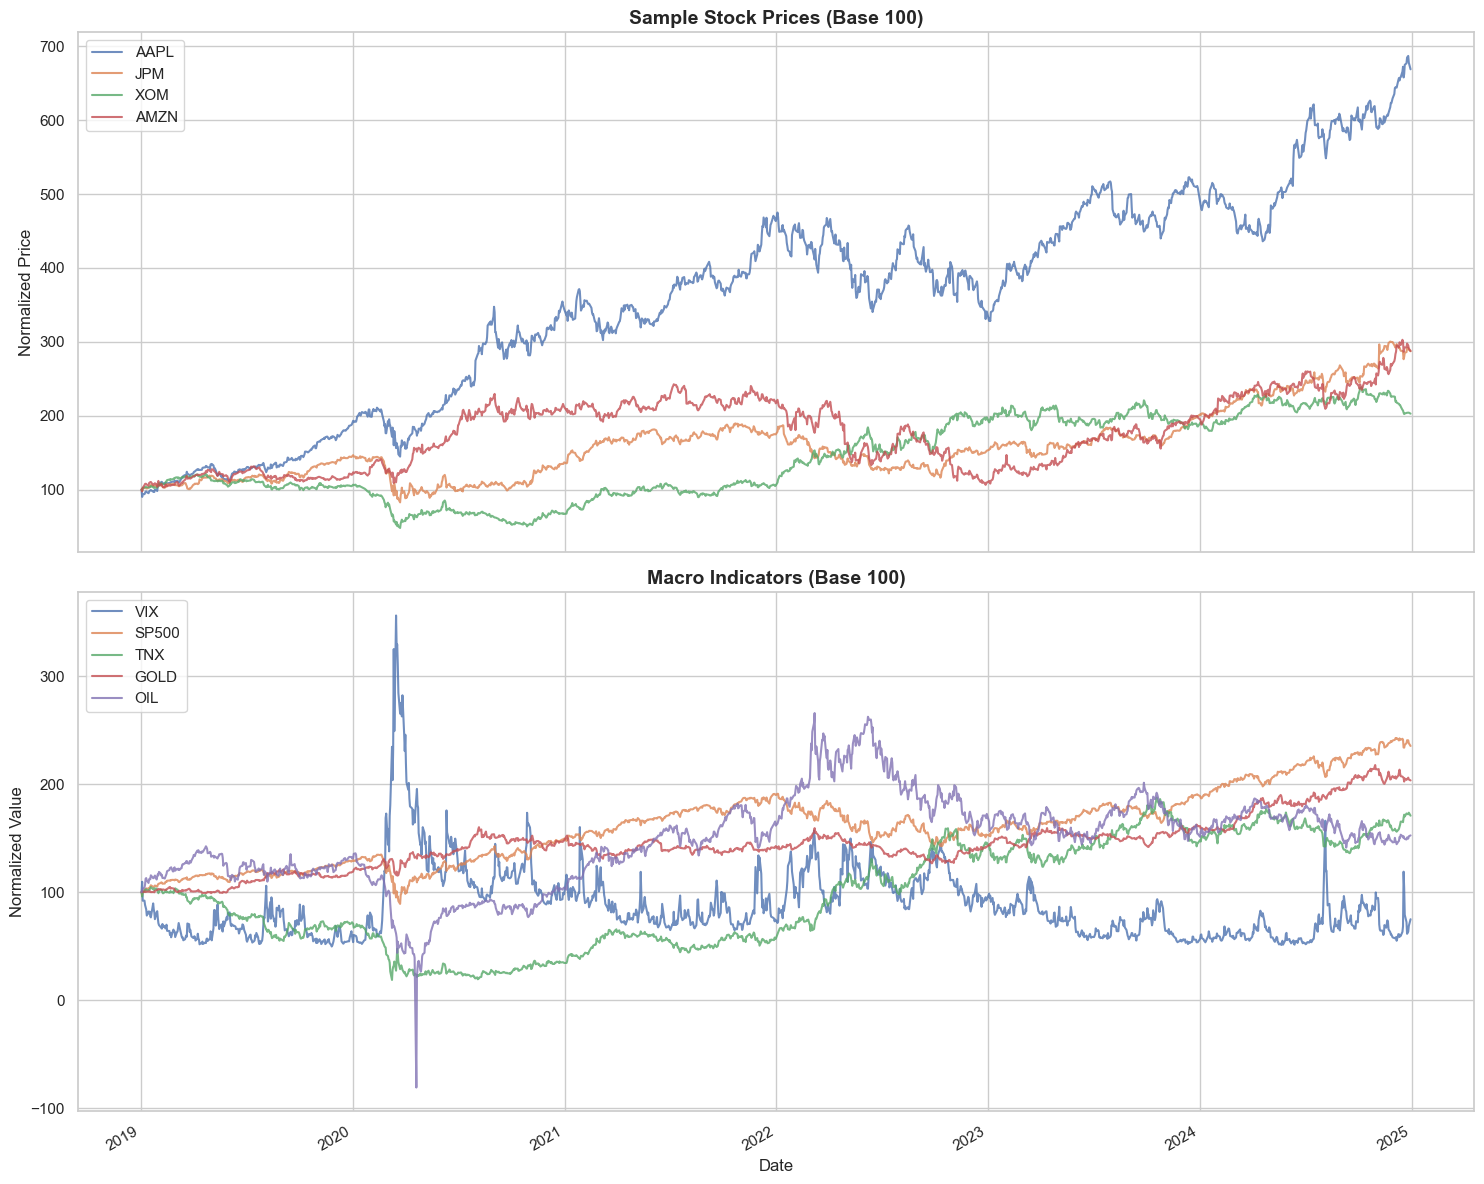

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(15, 12), sharex=True)

# Plot a few representative stocks (normalized to 100)
sample_tickers = ['AAPL', 'JPM', 'XOM', 'AMZN']
prices_norm = prices[sample_tickers] / prices[sample_tickers].iloc[0] * 100
prices_norm.plot(ax=axes[0], alpha=0.8)
axes[0].set_title('Sample Stock Prices (Base 100)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Normalized Price')
axes[0].legend(loc='upper left')

# Plot Macro Indicators (normalized)
macro_norm = macro / macro.iloc[0] * 100
macro_norm.plot(ax=axes[1], alpha=0.8)
axes[1].set_title('Macro Indicators (Base 100)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Normalized Value')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

---
## Cell 6 — Data Validation

Before persisting any data, we run a systematic quality-control pass:

1. **Missing values** — identify tickers with >1% missing (may indicate data gaps or late listing)
2. **Duplicate dates** — duplicates would corrupt any time-series model
3. **Date continuity** — gaps larger than 5 calendar days (beyond typical holidays) signal issues

We use `assert` statements so the notebook will immediately surface a failure if
critical quality thresholds are breached.

In [6]:
print('=' * 60)
print('DATA VALIDATION REPORT')
print('=' * 60)

# ------------------------------------------------------------------
# 1. Missing values per ticker (as % of total rows)
# ------------------------------------------------------------------
print()
print('[1] Missing Values')
print('-' * 40)

pct_missing = (prices.isna().mean() * 100).round(3)
high_missing = pct_missing[pct_missing > 1.0]  # Flag tickers >1% missing

if high_missing.empty:
    print('    No ticker has >1% missing values ✓')
else:
    print('    Tickers with >1% missing (may need forward-fill or exclusion):')
    display(high_missing.to_frame('Missing%'))

# Show full summary table
display(
    pct_missing
    .sort_values(ascending=False)
    .rename('Missing%')
    .to_frame()
    .head(10)
)

# ------------------------------------------------------------------
# 2. Duplicate date check
# ------------------------------------------------------------------
print('[2] Duplicate Dates')
print('-' * 40)

prices_dups = prices.index.duplicated().sum()
macro_dups  = macro.index.duplicated().sum()

print(f'    prices duplicates : {prices_dups}')
print(f'    macro  duplicates : {macro_dups}')

# Hard assertion — duplicates would cause alignment bugs downstream
assert prices_dups == 0, f'Duplicate dates found in prices! ({prices_dups} dupes)'
assert macro_dups  == 0, f'Duplicate dates found in macro!  ({macro_dups}  dupes)'
print('    No duplicates detected ✓')

# ------------------------------------------------------------------
# 3. Date continuity — detect large calendar gaps
# ------------------------------------------------------------------
print()
print('[3] Date Continuity (calendar gaps > 5 days)')
print('-' * 40)

# Using calendar days; weekends account for ~2-3 day gaps, holidays may add 1-2 more
GAP_THRESHOLD_DAYS = 5

day_diffs  = pd.Series(prices.index).diff().dt.days.dropna()
large_gaps = day_diffs[day_diffs > GAP_THRESHOLD_DAYS]

if large_gaps.empty:
    print(f'    No calendar gaps > {GAP_THRESHOLD_DAYS} days detected ✓')
else:
    gap_dates = prices.index[large_gaps.index]
    print(f'    Found {len(large_gaps)} gap(s) > {GAP_THRESHOLD_DAYS} calendar days:')
    for gap_date, gap_size in zip(gap_dates, large_gaps.values):
        print(f'      {gap_date.date()}  —  {gap_size} calendar days')

print()
print('=' * 60)
print('VALIDATION COMPLETE')
print('=' * 60)

DATA VALIDATION REPORT

[1] Missing Values
----------------------------------------
    No ticker has >1% missing values ✓


,Missing%
Ticker,
AAPL,0.0
ABBV,0.0
WMT,0.0
V,0.0
UPS,0.0
UNH,0.0
TSLA,0.0
SLB,0.0
PFE,0.0


[2] Duplicate Dates
----------------------------------------
    prices duplicates : 0
    macro  duplicates : 0
    No duplicates detected ✓

[3] Date Continuity (calendar gaps > 5 days)
----------------------------------------
    No calendar gaps > 5 days detected ✓

VALIDATION COMPLETE


### Visualizing Missing Data (Pre-Handling)

We use a heatmap to identify if missing values are concentrated in specific tickers or specific time periods.
White streaks indicate missing data.

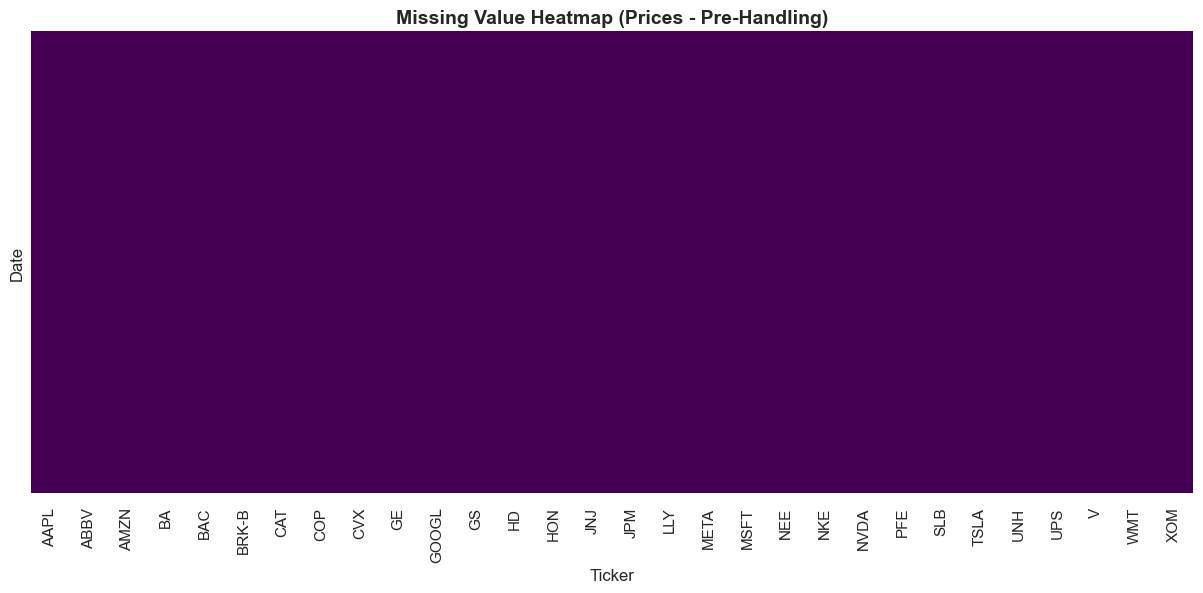

Total Missing Values: 0


In [7]:
plt.figure(figsize=(15, 6))
sns.heatmap(prices.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Value Heatmap (Prices - Pre-Handling)', fontsize=14, fontweight='bold')
plt.show()

print(f'Total Missing Values: {prices.isnull().sum().sum()}')

---
## Handling Missing Values

To ensure our models have continuous inputs, we apply:
1. **Forward Fill (FFILL)**: Carry the last known price forward (most common in finance to avoid look-ahead bias).
2. **Backward Fill (BFILL)**: Fill any remaining gaps at the beginning of the series.

In [8]:
print('Handling missing values...')

# Apply handling to both prices and macro
prices_clean = prices.ffill().bfill()
macro_clean = macro.ffill().bfill()

print(f'Prices Missing after handling: {prices_clean.isnull().sum().sum()}')
print(f'Macro  Missing after handling: {macro_clean.isnull().sum().sum()}')

# Verify with assertion
assert prices_clean.isnull().sum().sum() == 0, 'Gaps remain in prices data!'
assert macro_clean.isnull().sum().sum() == 0, 'Gaps remain in macro data!'

# Update global variables for saving
prices = prices_clean
macro = macro_clean

Handling missing values...
Prices Missing after handling: 0
Macro  Missing after handling: 0


### Visualizing Missing Data (Post-Handling)

The heatmap should now be solid, indicating all gaps have been filled.

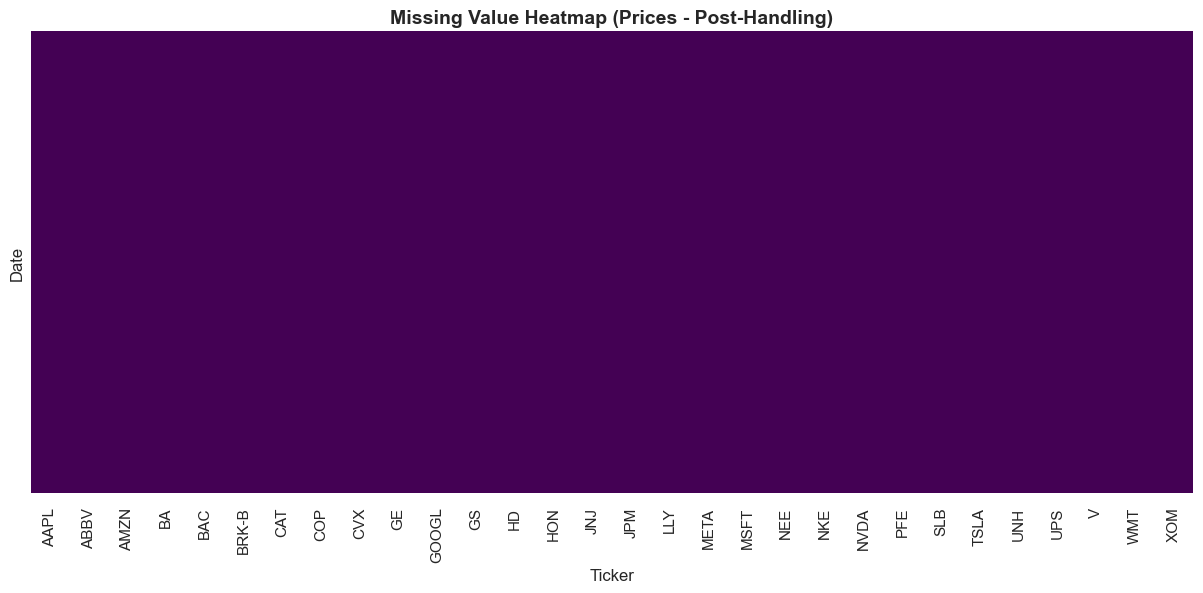

In [9]:
plt.figure(figsize=(15, 6))
sns.heatmap(prices.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Value Heatmap (Prices - Post-Handling)', fontsize=14, fontweight='bold')
plt.show()

---
## Cell 7 — Save Raw Data

We persist all raw data artifacts to `data/raw/` before any processing or transformation.
This follows the **raw-immutability principle**: downstream phases always read from processed/,
and we can always re-derive everything from these canonical raw files.

| File | Format | Contents |
|------|--------|----------|
| `prices.csv` | CSV | Adjusted daily close prices for all 30 tickers |
| `macro.csv` | CSV | 5 macroeconomic indicators |
| `sector_map.json` | JSON | Ticker → sector mapping dict |

In [10]:
# File paths
prices_path     = RAW_DIR / 'prices.csv'
macro_path      = RAW_DIR / 'macro.csv'
sector_map_path = RAW_DIR / 'sector_map.json'

# ------------------------------------------------------------------
# Save prices
# ------------------------------------------------------------------
prices.to_csv(prices_path)
assert prices_path.exists(), f'prices.csv was not written to {prices_path}'

# ------------------------------------------------------------------
# Save macro
# ------------------------------------------------------------------
macro.to_csv(macro_path)
assert macro_path.exists(), f'macro.csv was not written to {macro_path}'

# ------------------------------------------------------------------
# Save sector map as JSON
# ------------------------------------------------------------------
with open(sector_map_path, 'w') as f:
    json.dump(SECTOR_MAP, f, indent=2)
assert sector_map_path.exists(), f'sector_map.json was not written to {sector_map_path}'

# ------------------------------------------------------------------
# Confirmation + file sizes
# ------------------------------------------------------------------
def human_size(path: Path) -> str:
    """Return file size in KB or MB as a human-readable string."""
    bytes_ = path.stat().st_size
    if bytes_ >= 1_048_576:
        return f'{bytes_ / 1_048_576:.2f} MB'
    return f'{bytes_ / 1024:.1f} KB'

print('=' * 55)
print('FILES SAVED TO  data/raw/')
print('=' * 55)
print(f'  prices.csv     →  {human_size(prices_path)}')
print(f'  macro.csv      →  {human_size(macro_path)}')
print(f'  sector_map.json→  {human_size(sector_map_path)}')
print('=' * 55)
print()
print('All assertions passed — raw data is on disk ✓')

FILES SAVED TO  data/raw/
  prices.csv     →  823.1 KB
  macro.csv      →  144.0 KB
  sector_map.json→  0.7 KB

All assertions passed — raw data is on disk ✓


---
## Cell 8 — Phase 1 Summary

### ✅ What Was Downloaded

| Dataset | Tickers | Date Range | Format |
|---------|---------|------------|--------|
| Stock Prices | 30 equities across 6 sectors | 2019-01-01 → 2024-12-31 | `data/raw/prices.csv` |
| Macro Indicators | VIX, SP500, TNX, GOLD, OIL | 2019-01-01 → 2024-12-31 | `data/raw/macro.csv` |
| Sector Map | 30 ticker → sector mappings | — | `data/raw/sector_map.json` |

### 📊 Key Stats
- **Date range**: ~6 years of daily data (≈ 1,500 trading days)
- **Stock universe**: 30 tickers spanning Technology, Financials, Healthcare, Energy, Consumer, Industrials
- **Macro signals**: 5 regime indicators for cross-asset context
- **Failed downloads**: Logged in Cell 4 output (pipeline never crashed)
- **Data quality**: Validated for missing values, duplicate dates, and date continuity

### 🔜 What Comes Next — Phase 2: Feature Engineering

| Step | Description |
|------|-------------|
| Returns calculation | Log returns and rolling momentum signals |
| Technical indicators | RSI, MACD, Bollinger Bands, ATR |
| Cross-sectional features | Sector-relative z-scores, beta |
| Macro regime features | VIX regime flags, yield-curve slope |
| Feature persistence | Save processed features to `data/processed/` |

> **Phase 2 notebook**: `02_feature_engineering.ipynb`